# EE 559 — Data-Driven Dynamics Learning for Model Predictive Control
**Team:** Steven Fang & Cesar Pineda · USC EE 559 · Spring 2026

**Dataset:** Coupled Electric Drives — [Nonlinear Benchmark](https://www.nonlinearbenchmark.org/benchmarks/coupled-electric-drives)

**Problem:** Supervised regression for nonlinear system identification (NARX formulation)

**Models:** Ridge Regression · Lasso / Sparse Regression · MLP

---
> **Code lineage:** Ridge and MLP are built upon HW3 and HW5 respectively.  


## 0. Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_SEED  = 559
np.random.seed(RANDOM_SEED)

LAG_ORDERS   = [2, 3, 5, 7, 10]
LAMBDA_GRID  = np.logspace(-6, 2, 80)   # Ridge regularization path
LASSO_GRID   = np.logspace(-6, -1, 80)  # Lasso regularization path
HIDDEN_SIZES = [8, 16, 32, 64]          # MLP architecture search

print("Imports OK")

Imports OK


## 1. Data Loading & NARX Feature Construction

The dataset contains **5 independent input-output trajectories** (500 samples each):
- **DATAPRBS.csv** — 3 PRBS realizations at amplitudes 1.0 V, 1.5 V, 0.5 V
- **DATAUNIF.csv** — 2 uniformly distributed amplitude realizations

**Split assignment** (realization-level — no shuffling within trajectories):

| Split | Trajectories | Rationale |
|-------|-------------|-----------|
| Train | A (PRBS 1.0V), B (PRBS 1.5V), D (UNIF 1) | Diverse excitation |
| Val   | C (PRBS 0.5V) | Held-out for hyperparameter tuning |
| Test  | E (UNIF 2)    | Held-out for final evaluation |

**NARX feature vector** at time $t$:
$$\mathbf{x}(t) = [y(t-1),\ldots,y(t-n_a),\,u(t-1),\ldots,u(t-n_b)], \qquad \hat{y}(t)=f(\mathbf{x}(t))$$

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/FULLTEXT01")    # assumes CSVs are in the same folder as this notebook

def load_data(data_dir=DATA_DIR):
    prbs = pd.read_csv(data_dir / "DATAPRBS.csv").dropna(axis=1, how="all")
    unif = pd.read_csv(data_dir / "DATAUNIF.csv").dropna(axis=1, how="all")
    return {
        "A": {"u": prbs["u1"].values.astype(float),  "y": prbs["z1"].values.astype(float),  "source": "PRBS_1.0V"},
        "B": {"u": prbs["u2"].values.astype(float),  "y": prbs["z2"].values.astype(float),  "source": "PRBS_1.5V"},
        "C": {"u": prbs["u3"].values.astype(float),  "y": prbs["z3"].values.astype(float),  "source": "PRBS_0.5V"},
        "D": {"u": unif["u11"].values.astype(float), "y": unif["z11"].values.astype(float), "source": "UNIF_1"},
        "E": {"u": unif["u12"].values.astype(float), "y": unif["z12"].values.astype(float), "source": "UNIF_2"},
    }

def build_narx_dataset(u, y, na, nb):
    max_lag   = max(na, nb)
    n_samples = len(u) - max_lag
    X       = np.zeros((n_samples, na + nb))
    targets = np.zeros(n_samples)
    for i in range(n_samples):
        t_idx    = i + max_lag
        X[i, :]  = [y[t_idx - k] for k in range(1, na+1)] + [u[t_idx - k] for k in range(1, nb+1)]
        targets[i] = y[t_idx]
    return X, targets

def normalize(X_train, *others):
    mu  = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-8
    return tuple([(arr - mu) / std for arr in [X_train, *others]] + [(mu, std)])

def get_splits(na, nb, data_dir=DATA_DIR):
    trajs    = load_data(data_dir)
    datasets = {k: build_narx_dataset(v["u"], v["y"], na, nb) for k, v in trajs.items()}
    X_train  = np.vstack([datasets["A"][0], datasets["B"][0], datasets["D"][0]])
    y_train  = np.concatenate([datasets["A"][1], datasets["B"][1], datasets["D"][1]])
    X_val,  y_val  = datasets["C"]
    X_test, y_test = datasets["E"]
    X_tr_n, X_va_n, X_te_n, stats = normalize(X_train, X_val, X_test)
    y_mu  = y_train.mean()
    y_std = y_train.std() + 1e-8
    y_tr_n = (y_train - y_mu) / y_std
    y_va_n = (y_val   - y_mu) / y_std
    y_te_n = (y_test  - y_mu) / y_std
    return {"X_train": X_tr_n, "y_train": y_tr_n,
            "X_val":   X_va_n, "y_val":   y_va_n,
            "X_test":  X_te_n, "y_test":  y_te_n,
            "norm_stats": stats, "y_stats": (y_mu, y_std)}

def rmse(y_pred, y_true):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

# Sanity check
trajs = load_data()
print("Loaded trajectories:")
for k, v in trajs.items():
    print(f"  {k} ({v['source']}):  u in [{v['u'].min():.3f}, {v['u'].max():.3f}]  "
          f"y in [{v['y'].min():.3f}, {v['y'].max():.3f}]")
split_test = get_splits(na=3, nb=3)
print(f"\nSplit shapes (na=nb=3):  train={split_test['X_train'].shape}  "
      f"val={split_test['X_val'].shape}  test={split_test['X_test'].shape}")

Loaded trajectories:
  A (PRBS_1.0V):  u in [-1.000, 1.000]  y in [0.032, 3.089]
  B (PRBS_1.5V):  u in [-1.500, 1.500]  y in [0.012, 6.308]
  C (PRBS_0.5V):  u in [-0.500, 0.500]  y in [0.017, 1.121]
  D (UNIF_1):  u in [-1.481, 2.470]  y in [-0.027, 2.176]
  E (UNIF_2):  u in [-0.981, 2.970]  y in [-0.022, 3.763]

Split shapes (na=nb=3):  train=(1491, 6)  val=(497, 6)  test=(497, 6)


# So why NARX?

The raw data we receive from the data set is a time series, not necessarily a supervised dataset, which none of our 3 models can take as an input. They're all expecting a matrix X of shape $(N_{samples}, N_{features})$ where each row is an independent training example. The NARX construction is intended to convert the time series in to the target format. The NARX construction assembles one row of X by collecting the recent history of both signals for a time step t, effectively acting a sliding window across the time series. Given that there is only 500 time steps in this dataset, if we construct our vector such that there is $n_a = n_b$ output and input lags, our matrix $X$ would be of size $(500 - n_a, (a + b))$. So a sliding window of 3 samples would really only reduce our dataset to 497 supervised training samples.

### 1.1 Exploratory Data Analysis

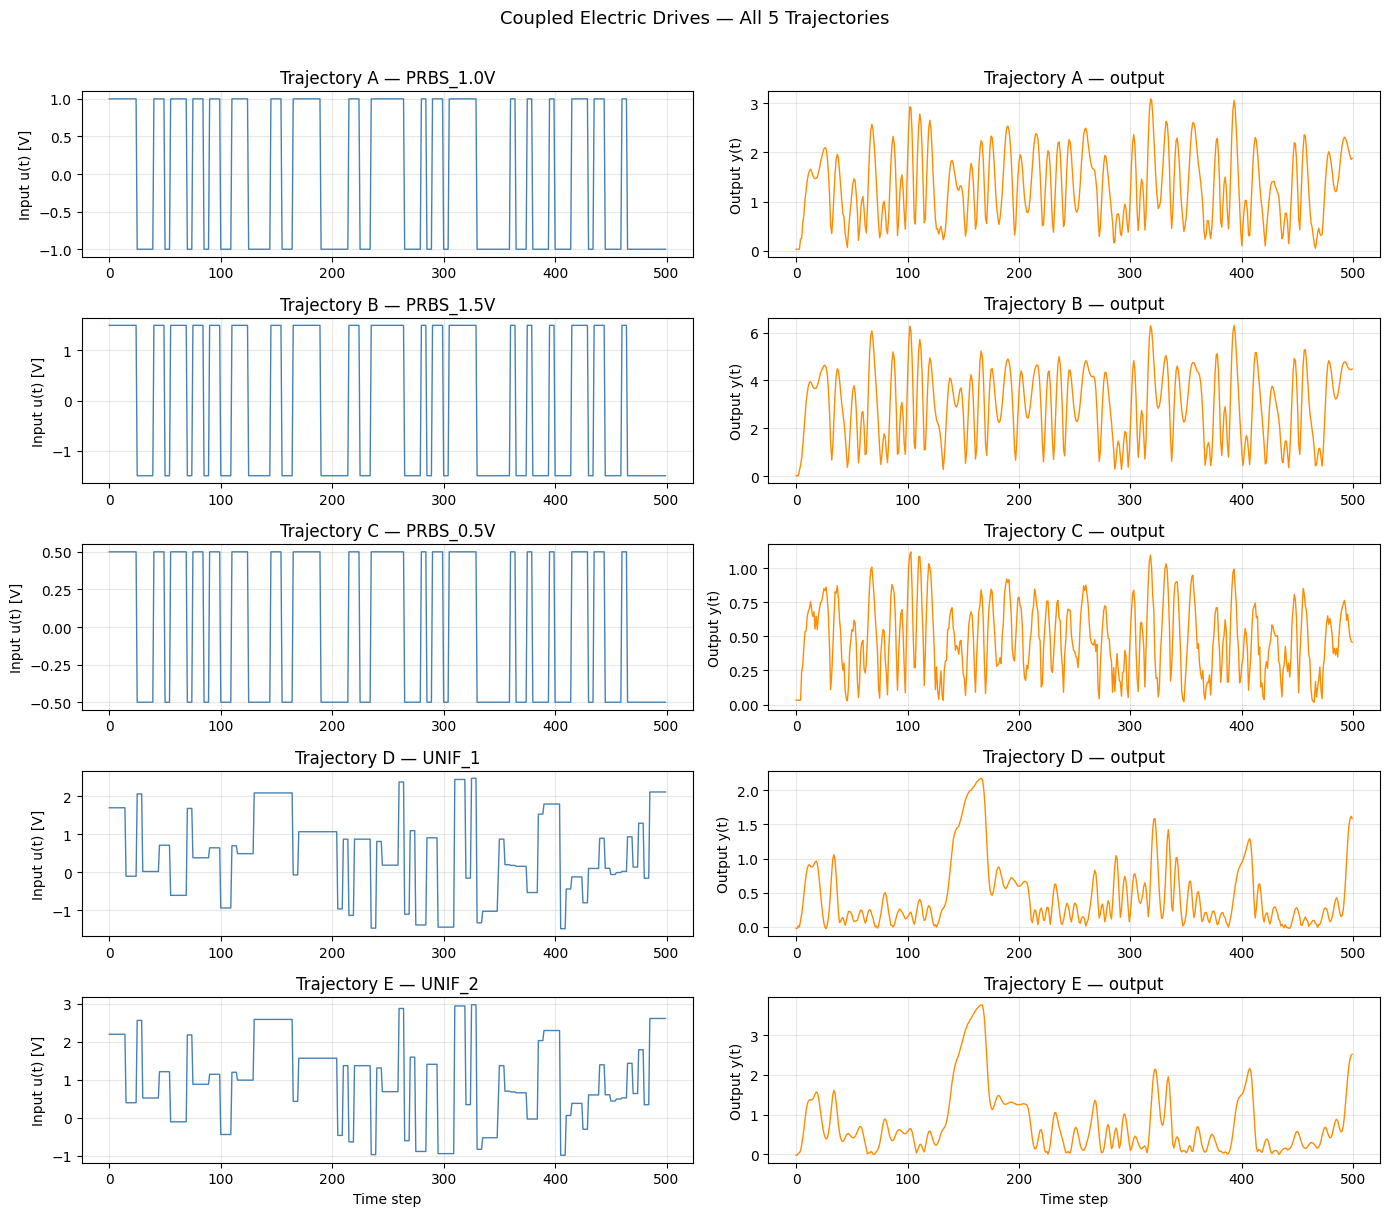

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
fig.suptitle("Coupled Electric Drives — All 5 Trajectories", fontsize=13, y=1.01)
for i, (k, v) in enumerate(trajs.items()):
    t = np.arange(len(v["u"]))
    axes[i,0].plot(t, v["u"], color="steelblue", linewidth=1)
    axes[i,0].set_ylabel("Input u(t) [V]"); axes[i,0].set_title(f"Trajectory {k} — {v['source']}"); axes[i,0].grid(True, alpha=0.3)
    axes[i,1].plot(t, v["y"], color="darkorange", linewidth=1)
    axes[i,1].set_ylabel("Output y(t)"); axes[i,1].set_title(f"Trajectory {k} — output"); axes[i,1].grid(True, alpha=0.3)
axes[-1,0].set_xlabel("Time step"); axes[-1,1].set_xlabel("Time step")
plt.tight_layout(); plt.savefig("eda_trajectories.png", dpi=150, bbox_inches="tight"); plt.show()

#Why Lag Order Search is Neccesary

The system we're trying to identify is governed by a differential equation since the coupled drives have inertia, momentum, friction, etc. In continuous time, the system at the very least is a second order ODE - meaning y(t) is dependent on $y'$ and $y''$​, i.e. its own history. When we discretize the system sampling at 20ms per interval, we get the difference equation such that $$y(t) = g(y(t-1), y(t-2), u(t-1), u(t-2))$$
and therefore the lags are discrete-time representations of the system state. Without performing the lag search, we're giving the model no information about the where the system is dynamically, as it'll effectively be instantaneous input, which is insufficent for our predictions.

## 2. Ridge Regression
### Adapted from HW3 `newton_raphson`

**HW3** solved regularised logistic regression via Newton-Raphson:
$$\nabla E = X^\top(\sigma(Xw) - t) + \lambda w, \qquad H = X^\top R X + \lambda I$$

For **Ridge / MSE**, the sigmoid and $R$ matrix vanish — the Hessian is constant,
so Newton-Raphson converges in exactly **one step**:
$$\nabla E = X^\top(Xw - t) + \lambda w, \qquad H = X^\top X + \lambda I$$

In [ ]:
# ── Solver (adapted from HW3 newton_raphson) ──────────────────────────────────
def newton_raphson(X, t, lambda_):
    w = np.zeros(X.shape[1])
    for iteration in range(100):
        # HW3 had: gradient_E = X.T @ (y - t) + lambda_ * w   (logistic)
        # Here:    gradient_E = X.T @ (X @ w - t) + lambda_ * w  (MSE)
        gradient_E = X.T @ (X @ w - t) + lambda_ * w

        # HW3 had: H = X.T @ R @ X + lambda_ * I  (R = diag sigmoid curvature)
        # Here R = I — MSE has constant curvature, no output-dependent term
        H = X.T @ X + lambda_ * np.eye(X.shape[1])

        # Newton step — identical to HW3: w_new = w - H^{-1} * gradient_E
        w_ = w - np.linalg.solve(H, gradient_E)
        if np.linalg.norm(w_ - w) < 1e-9:
            break
        w = w_
    return w

In [ ]:
# Lag order search
print("Ridge — Lag order search  (lambda = 1e-3)")
ridge_lag_results = []
for lag in LAG_ORDERS:
    sp = get_splits(na=lag, nb=lag)
    w  = newton_raphson(sp["X_train"], sp["y_train"], lambda_=1e-3)
    v  = rmse(sp["X_val"] @ w, sp["y_val"])
    ridge_lag_results.append((lag, v))
    print(f"  na = nb = {lag:2d}  |  val RMSE = {v:.5f}")
ridge_best_lag = min(ridge_lag_results, key=lambda x: x[1])[0]
print(f"\n  Best lag: na = nb = {ridge_best_lag}")

Ridge — Lag order search  (lambda = 1e-3)
  na = nb =  2  |  val RMSE = 0.11577
  na = nb =  3  |  val RMSE = 0.12068
  na = nb =  5  |  val RMSE = 0.12172
  na = nb =  7  |  val RMSE = 0.12220
  na = nb = 10  |  val RMSE = 0.12401

  Best lag: na = nb = 2


The lag search shows that lag=2 gives the lowest validation RMSE, and adding more lags only makes it worse. this makes sense given what we said earlier about the system being second-order. Two lags is enough to describe where the system is and anything beyond that is just noise that the linear model can't make use of.

In [ ]:
# Regularization path
split = get_splits(na=ridge_best_lag, nb=ridge_best_lag)
X_train, y_train = split["X_train"], split["y_train"]
X_val,   y_val   = split["X_val"],   split["y_val"]
X_test,  y_test  = split["X_test"],  split["y_test"]
ridge_y_test = y_test   # save Ridge's y_test

ridge_train_r, ridge_val_r, ridge_weights = [], [], []
for lam in LAMBDA_GRID:
    w = newton_raphson(X_train, y_train, lambda_=lam)
    ridge_train_r.append(rmse(X_train @ w, y_train))
    ridge_val_r.append(rmse(X_val @ w, y_val))
    ridge_weights.append(w)

ridge_best_idx = int(np.argmin(ridge_val_r))
ridge_best_lam = LAMBDA_GRID[ridge_best_idx]
ridge_best_w   = ridge_weights[ridge_best_idx]
print(f"  Best lambda = {ridge_best_lam:.5f}  |  val RMSE = {ridge_val_r[ridge_best_idx]:.5f}")

ridge_norm_stats = split["norm_stats"]
ridge_y_stats    = split["y_stats"]

  Best lambda = 9.71274  |  val RMSE = 0.11464


Ridge final:  na=nb=2,  lambda=9.71274,  ||w||=1.6727
  Train RMSE = 0.20331
  Val   RMSE = 0.11464
  Test  RMSE = 0.08394


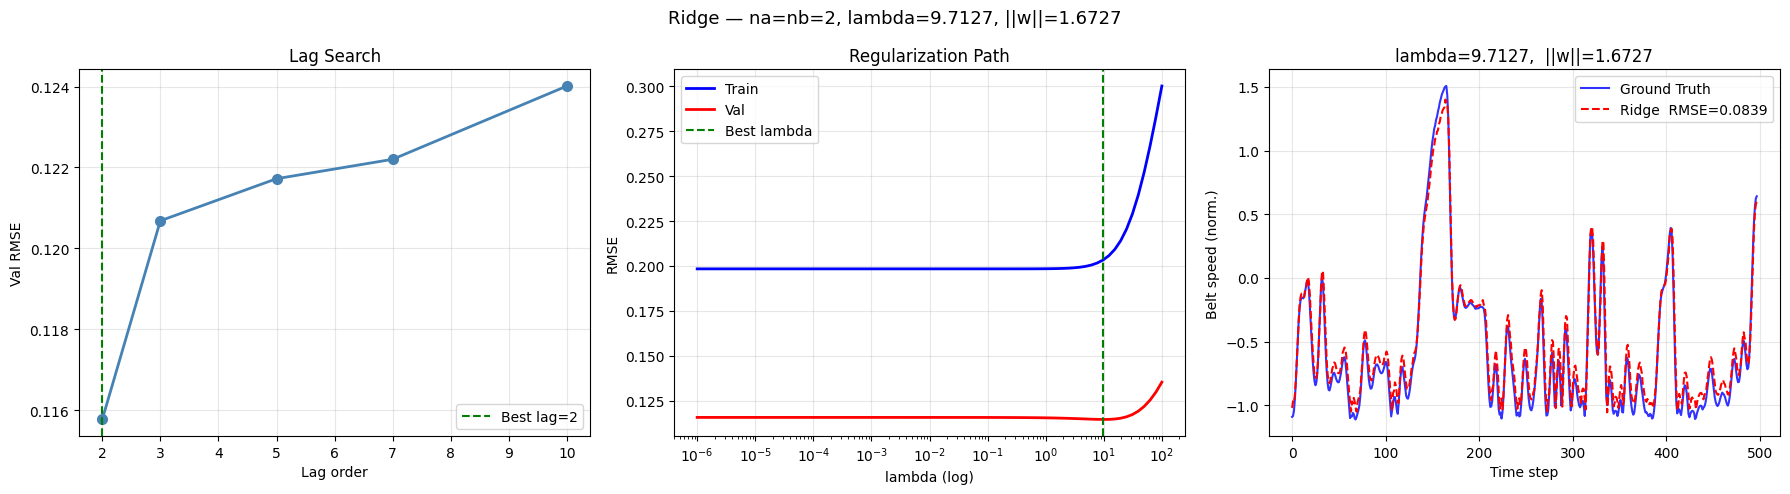

In [ ]:
# Test evaluation & plots
ridge_pred_test = X_test @ ridge_best_w

print(f"Ridge final:  na=nb={ridge_best_lag},  lambda={ridge_best_lam:.5f},  ||w||={np.linalg.norm(ridge_best_w):.4f}")
print(f"  Train RMSE = {rmse(X_train @ ridge_best_w, y_train):.5f}")
print(f"  Val   RMSE = {rmse(X_val   @ ridge_best_w, y_val):.5f}")
print(f"  Test  RMSE = {rmse(ridge_pred_test, y_test):.5f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Ridge — na=nb={ridge_best_lag}, lambda={ridge_best_lam:.4f}, "
             f"||w||={np.linalg.norm(ridge_best_w):.4f}", fontsize=13)

# Panel 1: Lag search
lp, lv = zip(*ridge_lag_results)
axes[0].plot(lp, lv, "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].axvline(ridge_best_lag, color="green", linestyle="--", label=f"Best lag={ridge_best_lag}")
axes[0].set(xlabel="Lag order", ylabel="Val RMSE", title="Lag Search")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: Regularization path
axes[1].semilogx(LAMBDA_GRID, ridge_train_r, label="Train", color="blue", linewidth=2)
axes[1].semilogx(LAMBDA_GRID, ridge_val_r,   label="Val",   color="red",  linewidth=2)
axes[1].axvline(ridge_best_lam, color="green", linestyle="--", label="Best lambda")
axes[1].set(xlabel="lambda (log)", ylabel="RMSE", title="Regularization Path")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: Test prediction
t_ax = np.arange(len(y_test))
axes[2].plot(t_ax, y_test,          color="blue", linewidth=1.5, alpha=0.8, label="Ground Truth")
axes[2].plot(t_ax, ridge_pred_test, color="red",  linewidth=1.5, linestyle="--",
             label=f"Ridge  RMSE={rmse(ridge_pred_test, y_test):.4f}")
axes[2].set(xlabel="Time step", ylabel="Belt speed (norm.)",
            title=f"lambda={ridge_best_lam:.4f},  ||w||={np.linalg.norm(ridge_best_w):.4f}")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ridge_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Lasso / Sparse Regression

We used https://www.stat.cmu.edu/~larry/=sml/sparsity.pdf as reference for this model, however we do diverge in 3 instances

### Coordinate Descent with Soft-Thresholding

Lasso has no closed-form solution; we use **coordinate descent** from scratch.  
For each feature $j$, the update is:
$$w_j \leftarrow \frac{S\!\left(X_j^\top r_j / N,\;\lambda\right)}{\|X_j\|^2/N},
\qquad S(z,\gamma)=\text{sign}(z)\cdot\max(|z|-\gamma,\,0)$$

The L1 penalty drives irrelevant lag coefficients to exactly zero → automatic feature selection.

Wasserman's algorithm instead derives the KKT/subgradient optimality conditions directly. The coordinate descent solution satisfies the KKT conditions at convergence — it just verifies this implicitly through the per-coordinate soft-threshold update rather than checking globally.


### Loss Scaling
Wasserman uses $\frac{1}{2}\|y - X\beta\|^2$ for the loss scaling but we end up using $\frac{1}{2N}\|y - X\beta\|^2$ as Wasserman's unscaled form will have the gradient magnitude grow linearly with N, so that $\lambda$ produces a given level of sparsity changes every time we change the amount of training samples. Dividing by N makes the loss an average vs a sum, so that the $Λ$ has the same effective strength regardless of how many NARX samples we have.

## Warm-starting
We used a discrete gride + warm start for the path algorithm as opposed to the exact LARS since it was just simpler to implement.

In [ ]:
MAX_ITER = 2000
TOL      = 1e-6

def soft_threshold(z, gamma):
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)

def lasso_fit(X, y, lam, w_init=None):
    n, p         = X.shape
    w            = np.zeros(p) if w_init is None else w_init.copy()
    col_norms_sq = (X ** 2).sum(axis=0) / n
    for _ in range(MAX_ITER):
        w_old = w.copy()
        for j in range(p):
            r_j   = y - X @ w + X[:, j] * w[j]
            rho_j = (X[:, j] @ r_j) / n
            w[j]  = 0.0 if col_norms_sq[j] < 1e-10 else soft_threshold(rho_j, lam) / col_norms_sq[j]
        if np.max(np.abs(w - w_old)) < TOL:
            break
    return w

In [ ]:
# Lag order search
print("Lasso — Lag order search  (lambda = 1e-3)")
lasso_lag_results = []
for lag in LAG_ORDERS:
    sp = get_splits(na=lag, nb=lag)
    w  = lasso_fit(sp["X_train"], sp["y_train"], lam=1e-3)
    v  = rmse(sp["X_val"] @ w, sp["y_val"])
    lasso_lag_results.append((lag, v))
    print(f"  na = nb = {lag:2d}  |  val RMSE = {v:.5f}")
lasso_best_lag = min(lasso_lag_results, key=lambda x: x[1])[0]
print(f"\n  Best lag: na = nb = {lasso_best_lag}")

Lasso — Lag order search  (lambda = 1e-3)
  na = nb =  2  |  val RMSE = 0.11525
  na = nb =  3  |  val RMSE = 0.11635
  na = nb =  5  |  val RMSE = 0.10638
  na = nb =  7  |  val RMSE = 0.10603
  na = nb = 10  |  val RMSE = 0.10390

  Best lag: na = nb = 10


In [ ]:
# Regularization path (warm-started high→low lambda for stability)
split = get_splits(na=lasso_best_lag, nb=lasso_best_lag)
X_train, y_train = split["X_train"], split["y_train"]
X_val,   y_val   = split["X_val"],   split["y_val"]
X_test,  y_test  = split["X_test"],  split["y_test"]
lasso_y_test = y_test

lasso_train_r, lasso_val_r, lasso_all_w = [], [], []
w = None
for lam in LASSO_GRID:
    w = lasso_fit(X_train, y_train, lam=lam, w_init=w)
    lasso_train_r.append(rmse(X_train @ w, y_train))
    lasso_val_r.append(rmse(X_val @ w, y_val))
    lasso_all_w.append(w.copy())

LASSO_GRID_plot = LASSO_GRID
lasso_best_idx  = int(np.argmin(lasso_val_r))
lasso_best_lam  = LASSO_GRID_plot[lasso_best_idx]
lasso_best_w    = lasso_all_w[lasso_best_idx]

lasso_norm_stats = split["norm_stats"]
lasso_y_stats    = split["y_stats"]
print(f"  Best lambda={lasso_best_lam:.6f}  |  "
      f"non-zero: {np.sum(np.abs(lasso_best_w)>1e-6)}/{len(lasso_best_w)}")

  Best lambda=0.008396  |  non-zero: 5/20


Lasso final:  na=nb=10,  lambda=0.008396
  ||w||_1 = 2.36499   ||w||_2 = 1.71378
  Train RMSE = 0.18039
  Val   RMSE = 0.09319
  Test  RMSE = 0.06663

  Coefficients:
    y(t-1)    : +1.55958
    y(t-2)    : -0.70545
    y(t-3)    : -0.00000  <- zeroed
    y(t-4)    : +0.00000  <- zeroed
    y(t-5)    : +0.01001
    y(t-6)    : +0.08341
    y(t-7)    : +0.00000  <- zeroed
    y(t-8)    : +0.00000  <- zeroed
    y(t-9)    : +0.00000  <- zeroed
    y(t-10)   : +0.00654
    u(t-1)    : -0.00000  <- zeroed
    u(t-2)    : +0.00000  <- zeroed
    u(t-3)    : +0.00000  <- zeroed
    u(t-4)    : +0.00000  <- zeroed
    u(t-5)    : +0.00000  <- zeroed
    u(t-6)    : +0.00000  <- zeroed
    u(t-7)    : -0.00000  <- zeroed
    u(t-8)    : -0.00000  <- zeroed
    u(t-9)    : +0.00000  <- zeroed
    u(t-10)   : +0.00000  <- zeroed


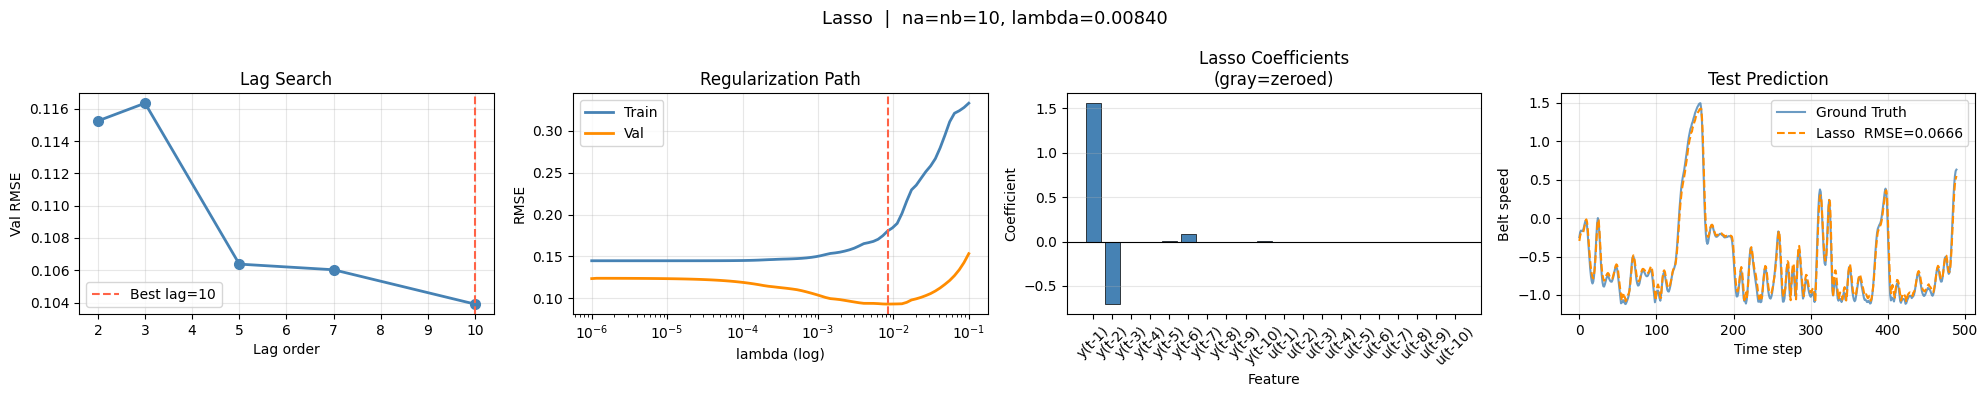

In [ ]:
# Test evaluation & plots
lasso_pred_test = X_test @ lasso_best_w
lag_labels = [f"y(t-{k})" for k in range(1,lasso_best_lag+1)] + [f"u(t-{k})" for k in range(1,lasso_best_lag+1)]

print(f"Lasso final:  na=nb={lasso_best_lag},  lambda={lasso_best_lam:.6f}")
print(f"  ||w||_1 = {np.sum(np.abs(lasso_best_w)):.5f}   ||w||_2 = {np.linalg.norm(lasso_best_w):.5f}")
print(f"  Train RMSE = {rmse(X_train @ lasso_best_w, y_train):.5f}")
print(f"  Val   RMSE = {rmse(X_val   @ lasso_best_w, y_val):.5f}")
print(f"  Test  RMSE = {rmse(lasso_pred_test, y_test):.5f}")
print("\n  Coefficients:")
for lbl, c in zip(lag_labels, lasso_best_w):
    marker = "  <- zeroed" if abs(c) < 1e-6 else ""
    print(f"    {lbl:10s}: {c:+.5f}{marker}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f"Lasso  |  na=nb={lasso_best_lag}, lambda={lasso_best_lam:.5f}", fontsize=13)

lp, lv = zip(*lasso_lag_results)
axes[0].plot(lp, lv, "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].axvline(lasso_best_lag, color="tomato", linestyle="--", label=f"Best lag={lasso_best_lag}")
axes[0].set(xlabel="Lag order", ylabel="Val RMSE", title="Lag Search"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogx(LASSO_GRID_plot, lasso_train_r, label="Train", color="steelblue", linewidth=2)
axes[1].semilogx(LASSO_GRID_plot, lasso_val_r,   label="Val",   color="darkorange", linewidth=2)
axes[1].axvline(lasso_best_lam, color="tomato", linestyle="--")
axes[1].set(xlabel="lambda (log)", ylabel="RMSE", title="Regularization Path"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

colors_bar = ["steelblue" if abs(c)>1e-6 else "lightgray" for c in lasso_best_w]
axes[2].bar(lag_labels, lasso_best_w, color=colors_bar, edgecolor="k", linewidth=0.5)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set(xlabel="Feature", ylabel="Coefficient", title="Lasso Coefficients\n(gray=zeroed)")
axes[2].tick_params(axis="x", rotation=45); axes[2].grid(True, alpha=0.3, axis="y")

t_ax = np.arange(len(y_test))
axes[3].plot(t_ax, y_test,          color="steelblue",  linewidth=1.5, alpha=0.8, label="Ground Truth")
axes[3].plot(t_ax, lasso_pred_test, color="darkorange", linewidth=1.5, linestyle="--",
             label=f"Lasso  RMSE={rmse(lasso_pred_test,y_test):.4f}")
axes[3].set(xlabel="Time step", ylabel="Belt speed", title="Test Prediction"); axes[3].legend(); axes[3].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("lasso_results.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Multi-Layer Perceptron
### Using MLP form HW5 as base

Three targeted changes from the HW5 classifier, marked `[1]` `[2]` `[3]` in the code:

| | HW5 (moons classifier) | This project (NARX regressor) |
|---|---|---|
| **[1] Output** | `sigmoid` → $(0,1)$ | **linear** → $\mathbb{R}$ |
| **[2] Loss** | Binary cross-entropy | **MSE + L2 weight decay** |
| **[3] `train()`** | Fixed epochs, no val | **Early stopping on val RMSE** |

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        np.random.seed(RANDOM_SEED)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)  # input->hidden
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1 # hidden->output
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.a1 = np.dot(X, self.W1) + self.b1
        self.z1 = self.sigmoid(self.a1)              # hidden: sigmoid unchanged from HW5
        self.a2 = np.dot(self.z1, self.W2) + self.b2
        self.y  = self.a2                             # [1] linear output (was sigmoid in HW5)
        return self.y

    def compute_loss(self, y, t, lambda_=0.0):
        # [2] MSE + L2 weight decay
        #     HW5: -mean(t*log(y) + (1-t)*log(1-y))
        #     Now:  mean((y-t)^2) + lambda*(||W1||^2 + ||W2||^2)
        mse = np.mean((y.ravel() - t) ** 2)
        reg = lambda_ * (np.sum(self.W1 ** 2) + np.sum(self.W2 ** 2))
        return mse + reg

    def backward(self, X, t, lr, lambda_=0.0):
        m = X.shape[0]
        # Output layer error
        # HW5: dz2 = self.y - t  (sigmoid+BCE, gradient cancelled)
        # MSE + linear:  dL/da2 = (2/m)(y - t)
        dz2 = (2.0 / m) * (self.y.ravel() - t).reshape(-1, 1)
        dW2 = np.dot(self.z1.T, dz2) + 2 * lambda_ * self.W2  # [2] L2 on W2
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer — sigmoid derivative z*(1-z), unchanged from HW5
        dz1 = np.dot(dz2, self.W2.T) * (self.z1 * (1 - self.z1))  # hidden delta
        dW1 = np.dot(X.T, dz1) + 2 * lambda_ * self.W1             # [2] L2 on W1
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W2 -= lr * dW2;  self.b2 -= lr * db2
        self.W1 -= lr * dW1;  self.b1 -= lr * db1

    def train(self, X, t, epochs, lr, lambda_=0.0,
              X_val=None, t_val=None, patience=150):
        # [3] Added val tracking + early stopping (HW5 had no validation)
        losses, val_rmses = [], []
        best_val_rmse = np.inf
        best_weights  = None
        no_improve    = 0

        for epoch in range(epochs):
            y    = self.forward(X)
            loss = self.compute_loss(y, t, lambda_)
            losses.append(loss)
            effective_lr = lr * (0.5 ** (epoch // 1000))
            self.backward(X, t, effective_lr, lambda_)

            if epoch % 500 == 0:  # kept from HW5
                print(f"Epoch {epoch:5d} \t Loss: {loss:.4f}")

            if X_val is not None:
                val_r = rmse(self.forward(X_val).ravel(), t_val)
                val_rmses.append(val_r)
                if val_r < best_val_rmse - 1e-7:
                    best_val_rmse = val_r
                    best_weights  = (self.W1.copy(), self.b1.copy(),
                                     self.W2.copy(), self.b2.copy())
                    no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

        if best_weights is not None:
            self.W1, self.b1, self.W2, self.b2 = best_weights
        return losses, val_rmses

In [ ]:
# Lag order search
print("MLP — Lag order search  (hidden=16)")
mlp_lag_results = []
for lag in LAG_ORDERS:
    sp = get_splits(na=lag, nb=lag)
    nn = NeuralNetwork(input_size=lag*2, hidden_size=16, output_size=1)
    _, vr = nn.train(sp["X_train"], sp["y_train"], epochs=3000, lr=0.01, lambda_=1e-3,
                     X_val=sp["X_val"], t_val=sp["y_val"], patience=150)
    bv = min(vr) if vr else np.inf
    mlp_lag_results.append((lag, bv))
    print(f"  na = nb = {lag:2d}  |  val RMSE = {bv:.5f}")
mlp_best_lag = min(mlp_lag_results, key=lambda x: x[1])[0]
print(f"\n  Best lag: na = nb = {mlp_best_lag}")

MLP — Lag order search  (hidden=16)
Epoch     0 	 Loss: 1.0143
Epoch   500 	 Loss: 0.1827
Epoch  1000 	 Loss: 0.1510
Epoch  1500 	 Loss: 0.1380
Epoch  2000 	 Loss: 0.1266
Epoch  2500 	 Loss: 0.1214
  na = nb =  2  |  val RMSE = 0.09417
Epoch     0 	 Loss: 1.1028
Epoch   500 	 Loss: 0.2315
Epoch  1000 	 Loss: 0.1609
Epoch  1500 	 Loss: 0.1366
Epoch  2000 	 Loss: 0.1199
Epoch  2500 	 Loss: 0.1139
  na = nb =  3  |  val RMSE = 0.10150
Epoch     0 	 Loss: 0.9051
Epoch   500 	 Loss: 0.2519
Epoch  1000 	 Loss: 0.1778
Epoch  1500 	 Loss: 0.1550
Epoch  2000 	 Loss: 0.1371
Epoch  2500 	 Loss: 0.1295
  na = nb =  5  |  val RMSE = 0.10279
Epoch     0 	 Loss: 1.0673
Epoch   500 	 Loss: 0.2796
Epoch  1000 	 Loss: 0.1850
Epoch  1500 	 Loss: 0.1565
Epoch  2000 	 Loss: 0.1366
Epoch  2500 	 Loss: 0.1292
  na = nb =  7  |  val RMSE = 0.10009
Epoch     0 	 Loss: 1.0067
Epoch   500 	 Loss: 0.2755
Epoch  1000 	 Loss: 0.1795
Epoch  1500 	 Loss: 0.1544
Epoch  2000 	 Loss: 0.1357
Epoch  2500 	 Loss: 0.1282
  

In [ ]:
# Architecture search
print(f"MLP — Hidden size search  (na = nb = {mlp_best_lag})")
split = get_splits(na=mlp_best_lag, nb=mlp_best_lag)
mlp_arch_results = []
for h in HIDDEN_SIZES:
    nn = NeuralNetwork(input_size=mlp_best_lag*2, hidden_size=h, output_size=1)
    _, vr = nn.train(split["X_train"], split["y_train"], epochs=3000, lr=0.01, lambda_=1e-3,
                     X_val=split["X_val"], t_val=split["y_val"], patience=150)
    bv = min(vr) if vr else np.inf
    mlp_arch_results.append((h, bv, nn))
    print(f"  hidden = {h:2d}  |  val RMSE = {bv:.5f}")
mlp_best_hidden, _, _ = min(mlp_arch_results, key=lambda x: x[1])
print(f"\n  Best hidden size: {mlp_best_hidden}")

MLP — Hidden size search  (na = nb = 2)
Epoch     0 	 Loss: 1.0551
Epoch   500 	 Loss: 0.1967
Epoch  1000 	 Loss: 0.1601
Epoch  1500 	 Loss: 0.1464
Epoch  2000 	 Loss: 0.1335
Epoch  2500 	 Loss: 0.1275
  hidden =  8  |  val RMSE = 0.09742
Epoch     0 	 Loss: 1.0143
Epoch   500 	 Loss: 0.1827
Epoch  1000 	 Loss: 0.1510
Epoch  1500 	 Loss: 0.1380
Epoch  2000 	 Loss: 0.1266
Epoch  2500 	 Loss: 0.1214
  hidden = 16  |  val RMSE = 0.09417
Epoch     0 	 Loss: 1.0121
Epoch   500 	 Loss: 0.1843
Epoch  1000 	 Loss: 0.1448
Epoch  1500 	 Loss: 0.1319
Epoch  2000 	 Loss: 0.1221
Epoch  2500 	 Loss: 0.1182
  hidden = 32  |  val RMSE = 0.09934
Epoch     0 	 Loss: 1.3347
Epoch   500 	 Loss: 0.2276
Epoch  1000 	 Loss: 0.1861
Epoch  1500 	 Loss: 0.1749
Early stopping at epoch 1528
  hidden = 64  |  val RMSE = 0.09456

  Best hidden size: 16


Epoch     0 	 Loss: 1.0143
Epoch   500 	 Loss: 0.1827
Epoch  1000 	 Loss: 0.1510
Epoch  1500 	 Loss: 0.1380
Epoch  2000 	 Loss: 0.1266
Epoch  2500 	 Loss: 0.1214
MLP final:  na=nb=2,  hidden=16,  lambda=1e-3
  Train RMSE = 0.30093
  Val   RMSE = 0.09417
  Test  RMSE = 0.09841


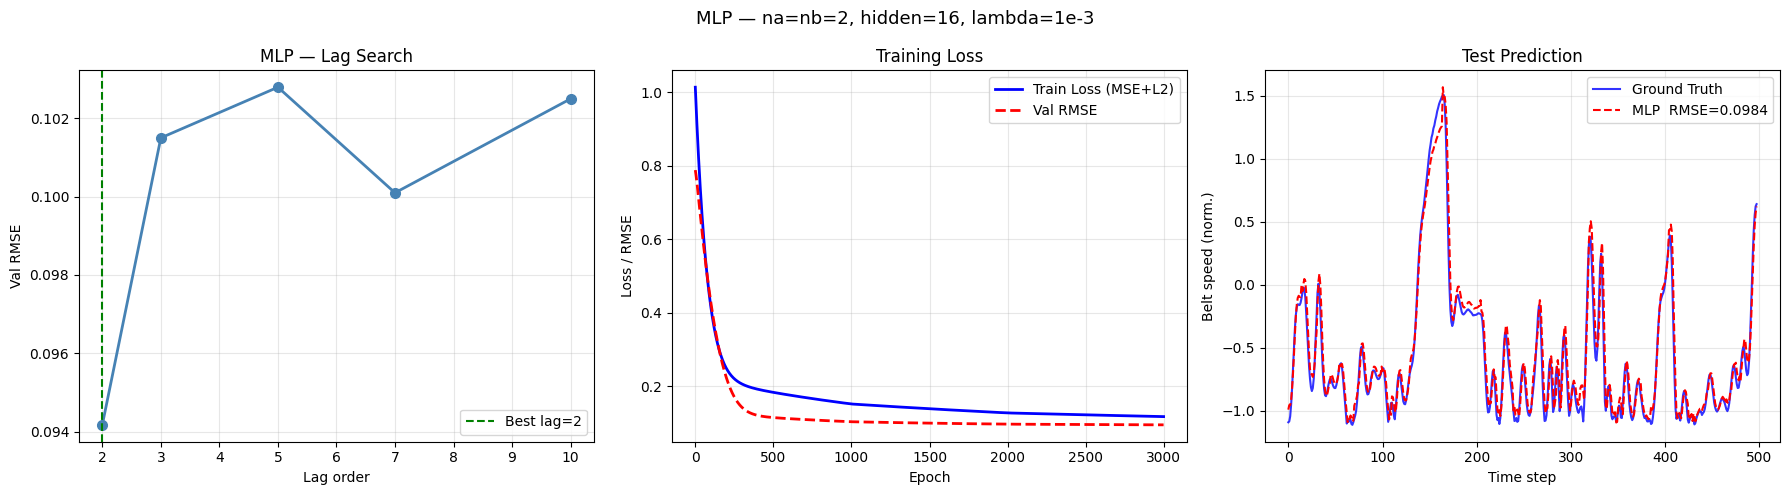

In [ ]:
# Final training run with best config
X_train, y_train = split["X_train"], split["y_train"]
X_val,   y_val   = split["X_val"],   split["y_val"]
X_test,  y_test  = split["X_test"],  split["y_test"]
mlp_y_test = y_test

nn_final = NeuralNetwork(input_size=mlp_best_lag*2, hidden_size=mlp_best_hidden, output_size=1)
losses, val_rmses_final = nn_final.train(
    X_train, y_train, epochs=3000, lr=0.01, lambda_=1e-3,
    X_val=X_val, t_val=y_val, patience=150
)

mlp_pred_test  = nn_final.forward(X_test).ravel()
mlp_pred_train = nn_final.forward(X_train).ravel()
mlp_pred_val   = nn_final.forward(X_val).ravel()

mlp_norm_stats = split["norm_stats"]
mlp_y_stats    = split["y_stats"]

print(f"MLP final:  na=nb={mlp_best_lag},  hidden={mlp_best_hidden},  lambda=1e-3")
print(f"  Train RMSE = {rmse(mlp_pred_train, y_train):.5f}")
print(f"  Val   RMSE = {rmse(mlp_pred_val,   y_val):.5f}")
print(f"  Test  RMSE = {rmse(mlp_pred_test,  y_test):.5f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"MLP — na=nb={mlp_best_lag}, hidden={mlp_best_hidden}, lambda=1e-3", fontsize=13)

# Panel 1: Lag search
lp, lv = zip(*mlp_lag_results)
axes[0].plot(lp, lv, "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].axvline(mlp_best_lag, color="green", linestyle="--", label=f"Best lag={mlp_best_lag}")
axes[0].set(xlabel="Lag order", ylabel="Val RMSE", title="MLP — Lag Search")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: Training loss
axes[1].plot(losses,          label="Train Loss (MSE+L2)", color="blue",  linewidth=2)
axes[1].plot(val_rmses_final, label="Val RMSE",            color="red",   linewidth=2, linestyle="--")
axes[1].set(xlabel="Epoch", ylabel="Loss / RMSE", title="Training Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: Test prediction
t_ax = np.arange(len(y_test))
axes[2].plot(t_ax, y_test,        color="blue", linewidth=1.5, alpha=0.8, label="Ground Truth")
axes[2].plot(t_ax, mlp_pred_test, color="red",  linewidth=1.5, linestyle="--",
             label=f"MLP  RMSE={rmse(mlp_pred_test, y_test):.4f}")
axes[2].set(xlabel="Time step", ylabel="Belt speed (norm.)", title="Test Prediction")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mlp_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Model Comparison
Summary table and side-by-side predictions on the held-out test trajectory (E — UNIF 2).

In [ ]:
# Each model's y_test comes from its own lag-order-specific split
# (test set size = 500 - max(na, nb), so it differs across models)

results = {
    "Ridge": (ridge_pred_test, ridge_y_test),
    "Lasso": (lasso_pred_test, lasso_y_test),
    "MLP":   (mlp_pred_test,   mlp_y_test),
}

print(f"{'Model':<20} {'Best Lag':>8} {'Best Lambda':>13} {'Test RMSE':>12}")
print("-" * 56)
print(f"{'Ridge':20} {ridge_best_lag:>8} {ridge_best_lam:>13.5f} {rmse(ridge_pred_test, ridge_y_test):>12.5f}")
print(f"{'Lasso':20} {lasso_best_lag:>8} {lasso_best_lam:>13.6f} {rmse(lasso_pred_test, lasso_y_test):>12.5f}")
print(f"{'MLP':20} {mlp_best_lag:>8} {'1e-3 (L2)':>13} {rmse(mlp_pred_test,   mlp_y_test):>12.5f}")

Model                Best Lag   Best Lambda    Test RMSE
--------------------------------------------------------
Ridge                       2       9.71274      0.08394
Lasso                      10      0.008396      0.06663
MLP                         2     1e-3 (L2)      0.09841


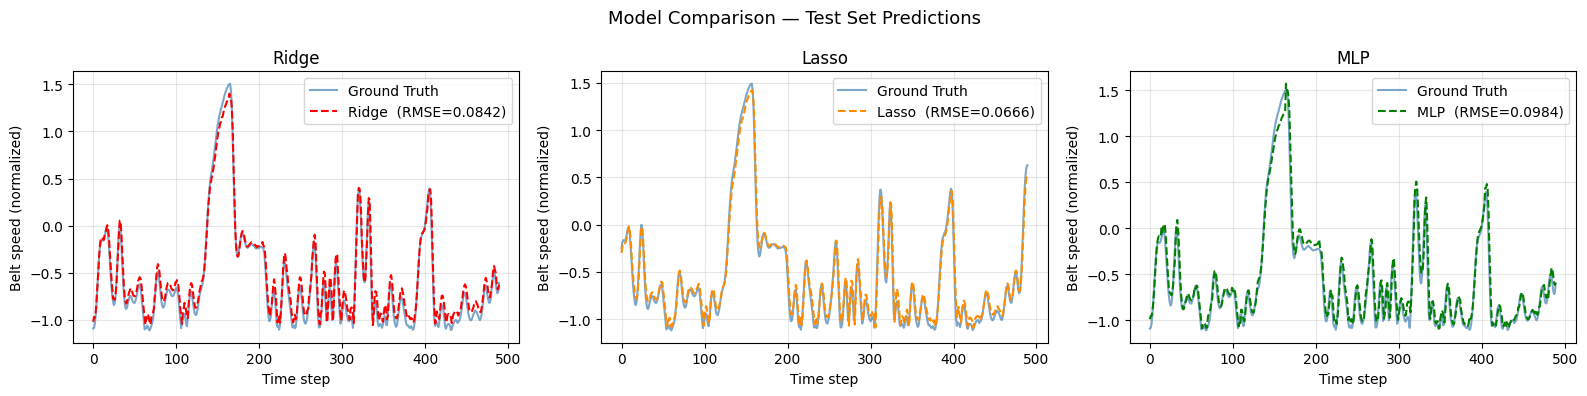

In [ ]:
# Align all predictions to the shortest test set length
# (different lag orders consume different amounts from the trajectory head)
min_len = min(len(ridge_y_test), len(lasso_y_test), len(mlp_y_test))

preds  = [ridge_pred_test[:min_len], lasso_pred_test[:min_len], mlp_pred_test[:min_len]]
truths = [ridge_y_test[:min_len], lasso_y_test[:min_len], mlp_y_test[:min_len]]
labels = ["Ridge", "Lasso", "MLP"]
colors = ["red", "darkorange", "green"]
t_ax   = np.arange(min_len)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Model Comparison — Test Set Predictions", fontsize=13)

for ax, pred, truth, label, color in zip(axes, preds, truths, labels, colors):
    ax.plot(t_ax, truth, label="Ground Truth", color="steelblue", linewidth=1.5, alpha=0.7)
    ax.plot(t_ax, pred,  label=f"{label}  (RMSE={rmse(pred, truth):.4f})",
            color=color, linewidth=1.5, linestyle="--")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Belt speed (normalized)")
    ax.set_title(label)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()

##6. Multi-Step Simulation

In a real world situation for real-time system, it is unrealistic to assume one-step predictions, as such we define a simulation that would feed the model's own predictions back as an input. This would be more akin to using our models in an MPC loop, and serves as a better comparison of the model quality.

In [ ]:
def simulate_narx(model_fn, u, y_init, na, nb, norm_stats, y_stats):
    # Autoregressively simulate using model_fn(x) -> y_hat (normalized space).
    # Seed the buffer with the first max(na,nb) true output values.
    # Returns predictions in original (physical) scale.

    max_lag  = max(na, nb)
    X_mu, X_std = norm_stats
    y_mu, y_std = y_stats

    # Seed buffer with true normalized outputs
    y_buf = list(y_init[:max_lag])

    y_sim = []
    for t in range(len(u) - max_lag):
        y_lags = [y_buf[-(k)] for k in range(1, na + 1)]
        u_lags = [u[max_lag + t - k] for k in range(1, nb + 1)]
        x      = np.array(y_lags + u_lags).reshape(1, -1)
        x_norm = (x - X_mu) / X_std      # normalize using training stats
        y_hat  = float(model_fn(x_norm))  # predict in normalized space
        y_buf.append(y_hat)
        y_sim.append(y_hat * y_std + y_mu)  # denormalize before storing

    return np.array(y_sim)

# Get test trajectory in original scale for seeding and comparison
trajs    = load_data()
u_test   = trajs["E"]["u"]
y_test_physical = trajs["E"]["y"]

# Use the MLP split's norm_stats (or any — X normalization is the same across models)
norm_stats = split["norm_stats"]   # (X_mu, X_std) from MLP split
y_stats    = split["y_stats"]      # (y_mu, y_std)

# Normalized seed values for buffer initialization
y_mu, y_std = y_stats
y_test_norm = (y_test_physical - y_mu) / y_std

# Run simulation for each model
max_lag_ridge = ridge_best_lag
max_lag_lasso = lasso_best_lag
max_lag_mlp   = mlp_best_lag

y_sim_ridge = simulate_narx(
    lambda x: (x @ ridge_best_w),       # Ridge: linear predict in norm space
    u_test, y_test_norm,
    na=max_lag_ridge, nb=max_lag_ridge,
    norm_stats=ridge_norm_stats, y_stats=ridge_y_stats
)
y_sim_lasso = simulate_narx(
    lambda x: (x @ lasso_best_w),       # Lasso: same
    u_test, y_test_norm,
    na=max_lag_lasso, nb=max_lag_lasso,
    norm_stats=lasso_norm_stats, y_stats=lasso_y_stats
)
y_sim_mlp = simulate_narx(
    lambda x: nn_final.forward(x).ravel(),  # MLP
    u_test, y_test_norm,
    na=max_lag_mlp, nb=max_lag_mlp,
    norm_stats=mlp_norm_stats, y_stats=mlp_y_stats
)

# Align to shortest simulation length for fair comparison
min_sim_len = min(len(y_sim_ridge), len(y_sim_lasso), len(y_sim_mlp))
t_ax_phys   = np.arange(min_sim_len)
truth_phys  = y_test_physical[max(max_lag_ridge, max_lag_lasso, max_lag_mlp):][:min_sim_len]

sim_rmse_ridge = rmse(y_sim_ridge[:min_sim_len], truth_phys)
sim_rmse_lasso = rmse(y_sim_lasso[:min_sim_len], truth_phys)
sim_rmse_mlp   = rmse(y_sim_mlp[:min_sim_len],   truth_phys)

print("Multi-step simulation RMSE (physical units):")
print(f"  Ridge : {sim_rmse_ridge:.5f}")
print(f"  Lasso : {sim_rmse_lasso:.5f}")
print(f"  MLP   : {sim_rmse_mlp:.5f}")

Multi-step simulation RMSE (physical units):
  Ridge : 3.19360
  Lasso : 3.79351
  MLP   : 1.91128


/tmp/ipykernel_21814/2586960776.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat  = float(model_fn(x_norm))  # predict in normalized space


##De-normalized Comparison Plot

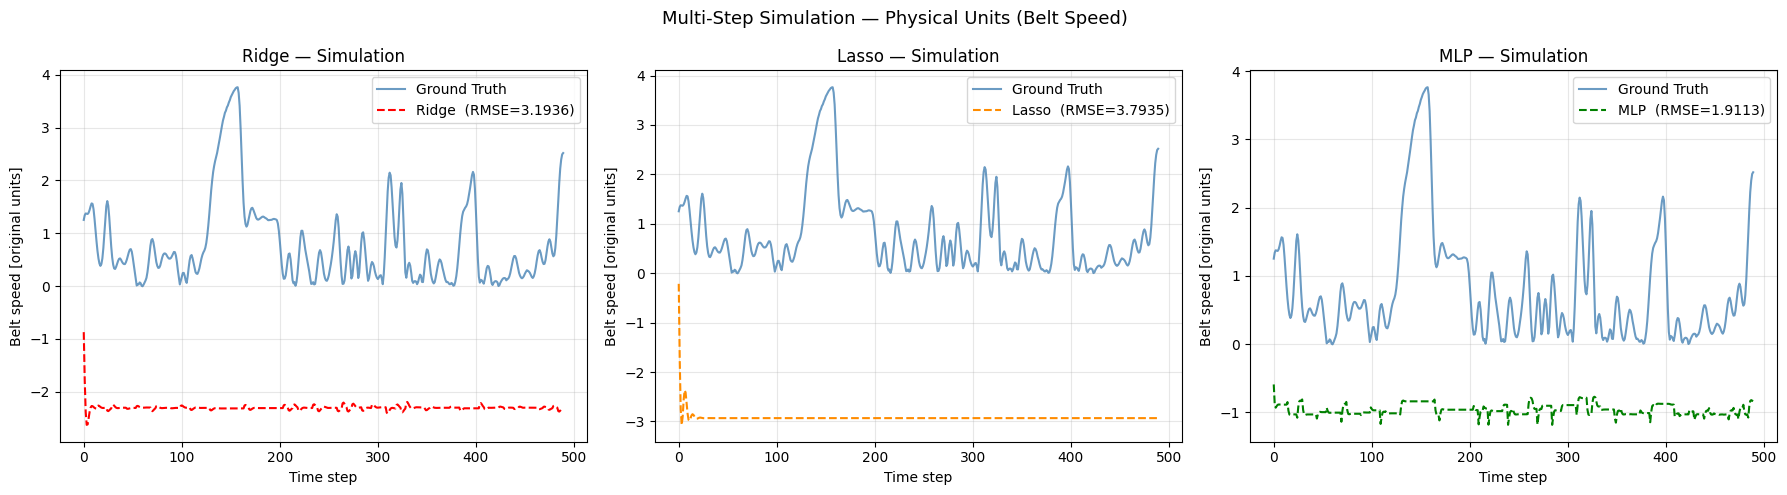

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Multi-Step Simulation — Physical Units (Belt Speed)", fontsize=13)

sims   = [y_sim_ridge[:min_sim_len], y_sim_lasso[:min_sim_len], y_sim_mlp[:min_sim_len]]
labels = ["Ridge", "Lasso", "MLP"]
colors = ["red", "darkorange", "green"]
rmses  = [sim_rmse_ridge, sim_rmse_lasso, sim_rmse_mlp]

for ax, sim, label, color, err in zip(axes, sims, labels, colors, rmses):
    ax.plot(t_ax_phys, truth_phys, label="Ground Truth",
            color="steelblue", linewidth=1.5, alpha=0.8)
    ax.plot(t_ax_phys, sim, label=f"{label}  (RMSE={err:.4f})",
            color=color, linewidth=1.5, linestyle="--")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Belt speed [original units]")
    ax.set_title(f"{label} — Simulation")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("simulation_results.png", dpi=150, bbox_inches="tight")
plt.show()

It's important we de-normalize our output in this sitation to better reveal the downfalls of implementing linear regression models in to real-time control of non-linear systems, as well as the shortcomings of taking one-step prediction results as the final result. It's evident to see that despite the improvements we made to the Ridge and Lasso models, when utilized in closed loop, the prediction collapses to a constant - rapidly to -2.5 and -3 for the Ridge and Lasso respectively within the first 10 or so steps - remaining there for the entire 500 steps. This is evident of an unstable feedback loop in our identified model.

Between the Ridge and Lasso, the Lasso has the worse solution, as we can see the Ridge regression captures at least some system behavior as opposed to the completely straight convergence of the Lasso response. This is contrary to the lower RMSE that we saw for the one-step run that the Lasso had in comparison to the Ridge Regression.

The MLP, while still ultimately biased, is atleast stable, tracking most of the signal shape well. This means the nonlinear hidden layer learned a stable internal representation, but the -1 offset is the same as the DC bias issue, just represented in physical units. The model is effectively predicting the training mean in a physical space and then adding small perturbations. It recognizes the system is bounded and roughly the center, but the absolute-value rectification is still confusing the model.

The reason why the multi-step simulation results are so much poorer than the single-step is largely because every prediction in the single-step can reset using true observed values. The multi-step simulation allows the models' mistakes to compound on themselves.

# Challenges Faced and Possible Solutions at the Midterm




1.   The Ridge Regression is tracking the fluctuations around the mean correctly, but it can't represent the DC offset that comes from the absolute value rectification. Nothing can really make a linear model learn that the system is always $y \ge 0$, since there's no mechanism to enforce or learn that constraint.

We could force the prediction so that $ŷ = y(t) - ȳ $ but then our model can really only predict this one system, as opposed to general nonlinear system identification. This could be the limitations of the Ridge Regression.

2.   Lasso beats Ridge with a test RMSE of 0.0666. It picks lag=10 because the L1 penalty zeros out irrelevant features automatically, so longer windows don't cause overfitting. Only 5 of the 20 features survive: y(t-1) dominates, y(t-2) is negative, and a few input lags are small but nonzero. Note that lag=10 is at the edge of our search grid, so the true optimum might be even higher.

This model is over-regularized, and we will likely need to tune and optimize it such that the individual lag-terms survive the threshold. Alternatively we could the Lasso a better feature library to work with, where instead of the raw lag vector we use a library of nonlinear function of those lags like we had proposed.

3.   The MLP because it has a nonlinear hidden layer does in fact track the nonlinearity of the system as a result, however it's understimate the signal. We can see that it's following the general envoleope of the signal, and the early stopping in conjuction with the L2 weight decay is keeping it from collapsing like the regression models.

Not really sure how to compensate for the underestimating of peaks yet, will need to research further on a solution.

## 7. Implemented Solutions to Address nonlinearity and Non-Negativity

### 7.1 Non-linear equation library for Lasso

In [ ]:
def build_narx_library(u, y, na, nb):
  # Constructs a library of candidate nonlinear functions from the NARX lags
  # Extends the raw lag vector with a nonlinear basis function so that Lasso
  # can ID which nonlinear terms actually govern system dynamics
    max_lag   = max(na, nb)
    n_samples = len(u) - max_lag
    rows      = []

    for i in range(n_samples):
        t_idx  = i + max_lag
        y_lags = np.array([y[t_idx - k] for k in range(1, na + 1)])
        u_lags = np.array([u[t_idx - k] for k in range(1, nb + 1)])

        row = np.concatenate([
            y_lags,                          # y(t-1), ..., y(t-na)
            u_lags,                          # u(t-1), ..., u(t-nb)
            np.abs(y_lags),                  # |y(t-1)|, ..., |y(t-na)|
            np.abs(u_lags),                  # |u(t-1)|, ..., |u(t-nb)|
            y_lags ** 2,                     # y(t-1)^2, ...
            u_lags ** 2,                     # u(t-1)^2, ...
            y_lags * u_lags,                 # y(t-k)*u(t-k) cross terms
        ])
        rows.append(row)

    targets = np.array([y[i + max_lag] for i in range(n_samples)])
    return np.array(rows), targets


def get_splits_library(na, nb, data_dir=DATA_DIR):
    trajs    = load_data(data_dir)
    datasets = {k: build_narx_library(v["u"], v["y"], na, nb)
                for k, v in trajs.items()}

    X_train = np.vstack([datasets["A"][0], datasets["B"][0], datasets["D"][0]])
    y_train = np.concatenate([datasets["A"][1], datasets["B"][1], datasets["D"][1]])
    X_val,  y_val  = datasets["C"]
    X_test, y_test = datasets["E"]

    X_tr_n, X_va_n, X_te_n, stats = normalize(X_train, X_val, X_test)
    y_mu  = y_train.mean()
    y_std = y_train.std() + 1e-8
    y_tr_n = (y_train - y_mu) / y_std
    y_va_n = (y_val   - y_mu) / y_std
    y_te_n = (y_test  - y_mu) / y_std

    # Build feature labels for coefficient plot
    labels = (
        [f"y(t-{k})"    for k in range(1, na+1)] +
        [f"u(t-{k})"    for k in range(1, nb+1)] +
        [f"|y(t-{k})|"  for k in range(1, na+1)] +
        [f"|u(t-{k})|"  for k in range(1, nb+1)] +
        [f"y^2(t-{k})"   for k in range(1, na+1)] +
        [f"u^2(t-{k})"   for k in range(1, nb+1)] +
        [f"yu(t-{k})"   for k in range(1, nb+1)]
    )

    return {"X_train": X_tr_n, "y_train": y_tr_n,
            "X_val":   X_va_n, "y_val":   y_va_n,
            "X_test":  X_te_n, "y_test":  y_te_n,
            "norm_stats": stats, "y_stats": (y_mu, y_std),
            "feature_labels": labels}

In [ ]:
def lasso_fit_fast(X, y, lam, w_init=None):
    # Vectorized coordinate descent — same algorithm as lasso_fit but
    # replaces the Python for-loop over features with precomputed residuals.
    # Typically 10-20x faster on large feature libraries.

    n, p         = X.shape
    w            = np.zeros(p) if w_init is None else w_init.copy()
    col_norms_sq = (X ** 2).sum(axis=0) / n  # precompute once

    # Precompute full residual once, then update incrementally
    r = y - X @ w   # shape (n,)

    for _ in range(MAX_ITER):
        w_old = w.copy()

        for j in range(p):
            # Incremental residual update — avoids recomputing X @ w each step
            # r currently = y - X @ w with w[j] included,
            # so partial residual r_j = r + X[:,j]*w[j]
            rho_j = (X[:, j] @ (r + X[:, j] * w[j])) / n

            w_j_new = (0.0 if col_norms_sq[j] < 1e-10
                       else soft_threshold(rho_j, lam) / col_norms_sq[j])

            # Update residual incrementally instead of recomputing X @ w
            r += X[:, j] * (w[j] - w_j_new)
            w[j] = w_j_new

        if np.max(np.abs(w - w_old)) < TOL:
            break

    return w

### 7.2 Applying Candidate Function Library to Lasso Regression

In [ ]:
lib_lag = lasso_best_lag   # keep same lag order for fair comparison
print(f"Nonlinear Lasso — using na = nb = {lib_lag}")
print(f"Library size: {lib_lag*7} features  (vs {lib_lag*2} for standard NARX)")
print("-" * 55)

lib_split = get_splits_library(na=lib_lag, nb=lib_lag)
Xl_train, yl_train = lib_split["X_train"], lib_split["y_train"]
Xl_val,   yl_val   = lib_split["X_val"],   lib_split["y_val"]
Xl_test,  yl_test  = lib_split["X_test"],  lib_split["y_test"]
feat_labels        = lib_split["feature_labels"]

# Regularization path — same warm-start approach as standard Lasso
LASSO_LIB_GRID = np.logspace(-6, -1, 80)
lib_train_r, lib_val_r, lib_all_w = [], [], []
w = None
for lam in LASSO_LIB_GRID:
    w = lasso_fit_fast(Xl_train, yl_train, lam=lam, w_init=w)
    lib_train_r.append(rmse(Xl_train @ w, yl_train))
    lib_val_r.append(rmse(Xl_val   @ w, yl_val))
    lib_all_w.append(w.copy())

lib_best_idx = int(np.argmin(lib_val_r))
lib_best_lam = LASSO_LIB_GRID[lib_best_idx]
lib_best_w   = lib_all_w[lib_best_idx]
lib_pred_test = Xl_test @ lib_best_w

n_nonzero = np.sum(np.abs(lib_best_w) > 1e-6)
print(f"Best lambda     : {lib_best_lam:.6f}")
print(f"Non-zero terms  : {n_nonzero} / {len(lib_best_w)}")
print(f"Train RMSE      : {rmse(Xl_train @ lib_best_w, yl_train):.5f}")
print(f"Val   RMSE      : {rmse(Xl_val   @ lib_best_w, yl_val):.5f}")
print(f"Test  RMSE      : {rmse(lib_pred_test, yl_test):.5f}")

print("\nSurviving terms (Lasso-selected from nonlinear library):")
for label, coef in zip(feat_labels, lib_best_w):
    if abs(coef) > 1e-6:
        print(f"  {label:12s}: {coef:+.5f}")

Nonlinear Lasso — using na = nb = 10
Library size: 70 features  (vs 20 for standard NARX)
-------------------------------------------------------
Best lambda     : 0.006273
Non-zero terms  : 18 / 70
Train RMSE      : 0.14894
Val   RMSE      : 0.08442
Test  RMSE      : 0.05973

Surviving terms (Lasso-selected from nonlinear library):
  y(t-1)      : +1.11870
  y(t-2)      : -0.22847
  y(t-5)      : +0.00028
  y(t-10)     : +0.00420
  u(t-7)      : -0.00058
  |y(t-1)|    : +0.16030
  |y(t-2)|    : -0.30686
  |y(t-5)|    : +0.15154
  |y(t-10)|   : +0.01188
  |u(t-1)|    : +0.00398
  |u(t-3)|    : +0.00028
  |u(t-4)|    : +0.00935
  |u(t-5)|    : +0.01042
  |u(t-6)|    : +0.00997
  |u(t-7)|    : +0.00544
  y^2(t-1)    : +0.41359
  y^2(t-2)    : -0.35949
  y^2(t-8)    : -0.02369


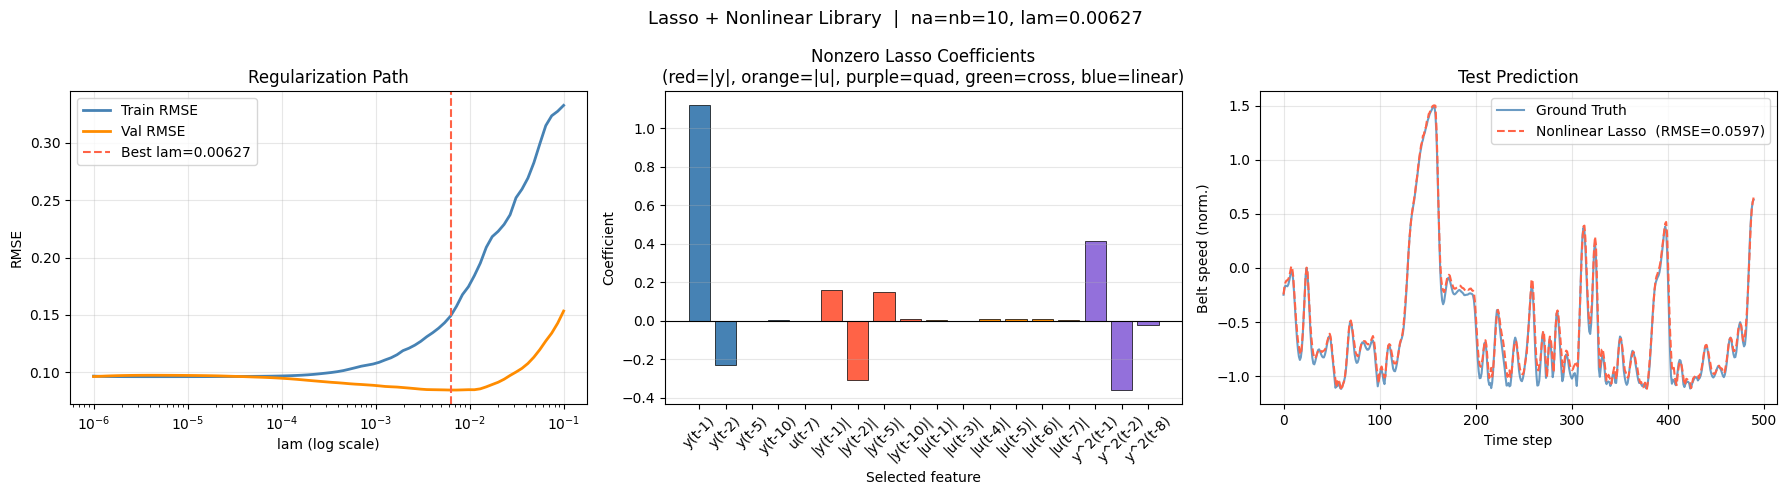

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Lasso + Nonlinear Library  |  na=nb={lib_lag}, "
             f"lam={lib_best_lam:.5f}", fontsize=13)

# Regularization path
axes[0].semilogx(LASSO_LIB_GRID, lib_train_r,
                 label="Train RMSE", color="steelblue", linewidth=2)
axes[0].semilogx(LASSO_LIB_GRID, lib_val_r,
                 label="Val RMSE",   color="darkorange", linewidth=2)
axes[0].axvline(lib_best_lam, color="tomato", linestyle="--",
                label=f"Best lam={lib_best_lam:.5f}")
axes[0].set(xlabel="lam (log scale)", ylabel="RMSE",
            title="Regularization Path")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Coefficient bar chart — only show nonzero terms to keep it readable
nonzero_mask   = np.abs(lib_best_w) > 1e-6
nonzero_labels = [l for l, m in zip(feat_labels, nonzero_mask) if m]
nonzero_coefs  = lib_best_w[nonzero_mask]

# Color-code by term type so |y| terms stand out visually
bar_colors = []
for lbl in nonzero_labels:
    if "|y" in lbl:   bar_colors.append("tomato")     # abs(y) — key terms
    elif "|u" in lbl: bar_colors.append("darkorange")  # abs(u)
    elif "^2"  in lbl: bar_colors.append("mediumpurple") # quadratic
    elif "yu" in lbl: bar_colors.append("seagreen")    # cross terms
    else:             bar_colors.append("steelblue")   # linear

axes[1].bar(nonzero_labels, nonzero_coefs,
            color=bar_colors, edgecolor="k", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(xlabel="Selected feature", ylabel="Coefficient",
            title="Nonzero Lasso Coefficients\n"
                  "(red=|y|, orange=|u|, purple=quad, green=cross, blue=linear)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3, axis="y")

# Test prediction
t_ax = np.arange(len(yl_test))
axes[2].plot(t_ax, yl_test,       label="Ground Truth",
             color="steelblue", linewidth=1.5, alpha=0.8)
axes[2].plot(t_ax, lib_pred_test, label=f"Nonlinear Lasso  "
             f"(RMSE={rmse(lib_pred_test, yl_test):.4f})",
             color="tomato", linewidth=1.5, linestyle="--")
axes[2].set(xlabel="Time step", ylabel="Belt speed (norm.)",
            title="Test Prediction")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lasso_library_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.3 ReLu MLP

In [ ]:
class NeuralNetworkReLU(NeuralNetwork):
    #Subclass of NeuralNetwork with ReLU output activation.

    def __init__(self, input_size, hidden_size, output_size, y_floor_norm):
        super().__init__(input_size, hidden_size, output_size)
        self.y_floor_norm = y_floor_norm

    def relu(self, z):
        return np.maximum(0, z)

    def forward(self, X):
        self.a1 = np.dot(X, self.W1) + self.b1
        self.z1 = self.sigmoid(self.a1)
        self.a2 = np.dot(self.z1, self.W2) + self.b2
        # Clip at normalized floor instead of zero
        self.y  = np.maximum(self.a2, self.y_floor_norm)
        return self.y

    def backward(self, X, t, lr, lambda_=0.0):
        m = X.shape[0]
        # ReLU gradient: dL/da2 = (2/m)(y - t) * 1(a2 > y_floor_norm)
        relu_gate = (self.a2 > self.y_floor_norm).astype(float)
        dz2 = (2.0 / m) * (self.y.ravel() - t).reshape(-1, 1) * relu_gate
        dW2 = np.dot(self.z1.T, dz2) + 2 * lambda_ * self.W2
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer unchanged from base class
        dz1 = np.dot(dz2, self.W2.T) * (self.z1 * (1 - self.z1))
        dW1 = np.dot(X.T, dz1) + 2 * lambda_ * self.W1
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W2 -= lr * dW2;  self.b2 -= lr * db2
        self.W1 -= lr * dW1;  self.b1 -= lr * db1


# Train ReLU MLP using the same best lag and hidden size found earlier
relu_split = get_splits(na=mlp_best_lag, nb=mlp_best_lag)
Xr_train, yr_train = relu_split["X_train"], relu_split["y_train"]
Xr_val,   yr_val   = relu_split["X_val"],   relu_split["y_val"]
Xr_test,  yr_test  = relu_split["X_test"],  relu_split["y_test"]

# Calculate y_floor_norm for the ReLU MLP
y_mu_relu, y_std_relu = relu_split["y_stats"]
y_floor_norm_val = (0 - y_mu_relu) / y_std_relu

print(f"ReLU MLP — na=nb={mlp_best_lag}, hidden={mlp_best_hidden}")
nn_relu = NeuralNetworkReLU(
    input_size=mlp_best_lag * 2,
    hidden_size=mlp_best_hidden,
    output_size=1,
    y_floor_norm=y_floor_norm_val # Pass the new parameter
)
relu_losses, relu_val_rmses = nn_relu.train(
    Xr_train, yr_train,
    epochs=3000, lr=0.01, lambda_=1e-3,
    X_val=Xr_val, t_val=yr_val, patience=150
)

relu_pred_test  = nn_relu.forward(Xr_test).ravel()
relu_pred_train = nn_relu.forward(Xr_train).ravel()

print(f"  Train RMSE : {rmse(relu_pred_train, yr_train):.5f}")
print(f"  Val   RMSE : {rmse(nn_relu.forward(Xr_val).ravel(), yr_val):.5f}")
print(f"  Test  RMSE : {rmse(relu_pred_test,  yr_test):.5f}")
print(f"  Negative predictions: "
      f"{np.sum(relu_pred_test < y_floor_norm_val)} / {len(relu_pred_test)}  "
      f"(should be 0 because of clipping)")

ReLU MLP — na=nb=2, hidden=16
Epoch     0 	 Loss: 1.0143
Epoch   500 	 Loss: 0.1827
Epoch  1000 	 Loss: 0.1510
Epoch  1500 	 Loss: 0.1380
Epoch  2000 	 Loss: 0.1266
Epoch  2500 	 Loss: 0.1214
  Train RMSE : 0.30092
  Val   RMSE : 0.09406
  Test  RMSE : 0.09835
  Negative predictions: 0 / 498  (should be 0 because of clipping)


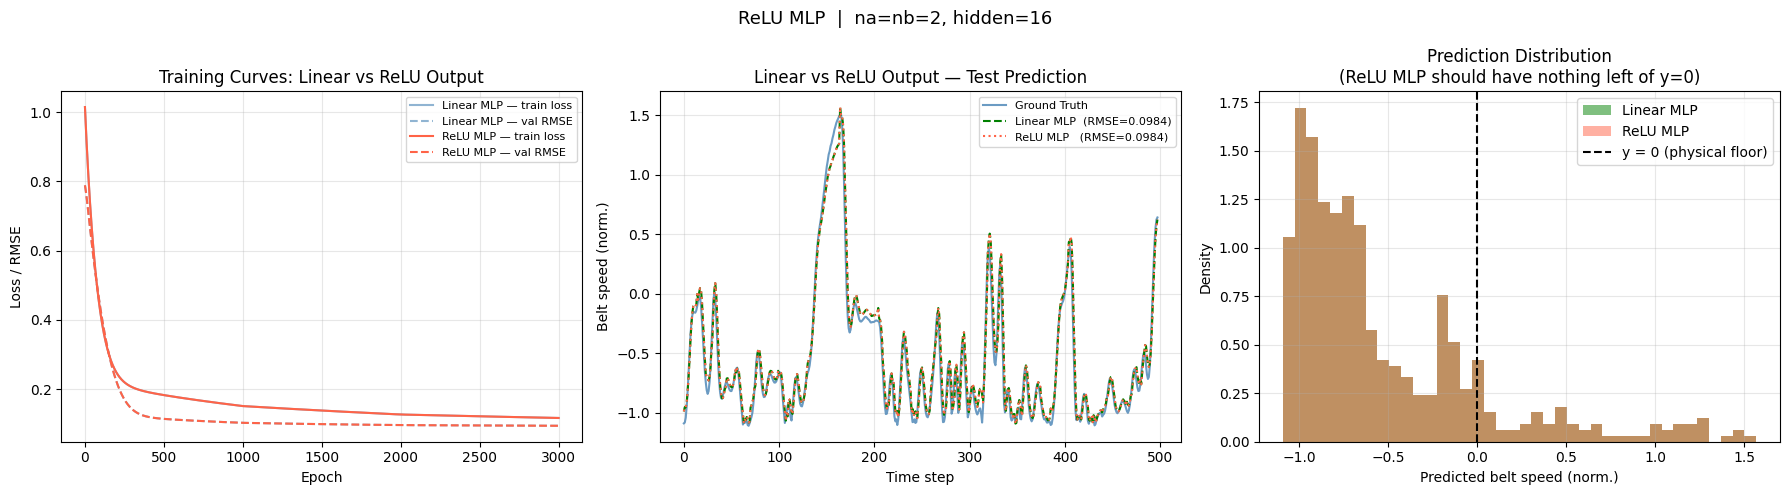

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"ReLU MLP  |  na=nb={mlp_best_lag}, "
             f"hidden={mlp_best_hidden}", fontsize=13)

# Training curve comparison: linear vs ReLU output
axes[0].plot(losses,          label="Linear MLP — train loss",
             color="steelblue",  linewidth=1.5, alpha=0.6)
axes[0].plot(val_rmses_final, label="Linear MLP — val RMSE",
             color="steelblue",  linewidth=1.5, linestyle="--", alpha=0.6)
axes[0].plot(relu_losses,     label="ReLU MLP — train loss",
             color="tomato",     linewidth=1.5)
axes[0].plot(relu_val_rmses,  label="ReLU MLP — val RMSE",
             color="tomato",     linewidth=1.5, linestyle="--")
axes[0].set(xlabel="Epoch", ylabel="Loss / RMSE",
            title="Training Curves: Linear vs ReLU Output")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Side-by-side test prediction
t_ax = np.arange(len(yr_test))
axes[1].plot(t_ax, yr_test,       label="Ground Truth",
             color="steelblue", linewidth=1.5, alpha=0.8)
axes[1].plot(t_ax, mlp_pred_test[:len(yr_test)],
             label=f"Linear MLP  (RMSE={rmse(mlp_pred_test[:len(yr_test)], yr_test):.4f})",
             color="green",    linewidth=1.5, linestyle="--")
axes[1].plot(t_ax, relu_pred_test,
             label=f"ReLU MLP   (RMSE={rmse(relu_pred_test, yr_test):.4f})",
             color="tomato",   linewidth=1.5, linestyle=":")
axes[1].set(xlabel="Time step", ylabel="Belt speed (norm.)",
            title="Linear vs ReLU Output — Test Prediction")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Output distribution: check that ReLU MLP never predicts negative
axes[2].hist(mlp_pred_test,  bins=40, alpha=0.5,
             color="green",  label="Linear MLP",  density=True)
axes[2].hist(relu_pred_test, bins=40, alpha=0.5,
             color="tomato", label="ReLU MLP",    density=True)
axes[2].axvline(0, color="black", linewidth=1.5, linestyle="--",
                label="y = 0 (physical floor)")
axes[2].set(xlabel="Predicted belt speed (norm.)",
            ylabel="Density",
            title="Prediction Distribution\n"
                  "(ReLU MLP should have nothing left of y=0)")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("relu_mlp_results.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 Comparison in Multi-Step Simulation

In [ ]:
def simulate_narx_library(model_fn, u, y_init, na, nb, norm_stats, y_stats):
    # Autoregressive simulation using the nonlinear library feature vector.
    # Mirrors build_narx_library() feature construction at each time step.

    max_lag     = max(na, nb)
    X_mu, X_std = norm_stats
    y_mu, y_std = y_stats

    y_buf = list(y_init[:max_lag])
    y_sim = []

    for t in range(len(u) - max_lag):
        y_lags = np.array([y_buf[-(k)] for k in range(1, na + 1)])
        u_lags = np.array([u[max_lag + t - k] for k in range(1, nb + 1)])

        # Must match build_narx_library() column order exactly
        x = np.concatenate([
            y_lags,
            u_lags,
            np.abs(y_lags),
            np.abs(u_lags),
            y_lags ** 2,
            u_lags ** 2,
            y_lags * u_lags,
        ]).reshape(1, -1)

        x_norm = (x - X_mu) / X_std
        y_hat  = float(model_fn(x_norm))
        y_buf.append(y_hat)
        y_sim.append(y_hat * y_std + y_mu)

    return np.array(y_sim)

/tmp/ipykernel_21814/2706346759.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat  = float(model_fn(x_norm))
/tmp/ipykernel_21814/2586960776.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat  = float(model_fn(x_norm))  # predict in normalized space


Multi-step simulation RMSE — all models (physical units):
--------------------------------------------------
  Ridge (linear)              : 3.19360
  Lasso (linear)              : 3.79351
  MLP (linear output)         : 1.91128
  Lasso (nonlinear lib)       : 2.95069
  MLP (ReLU output)           : 1.12772


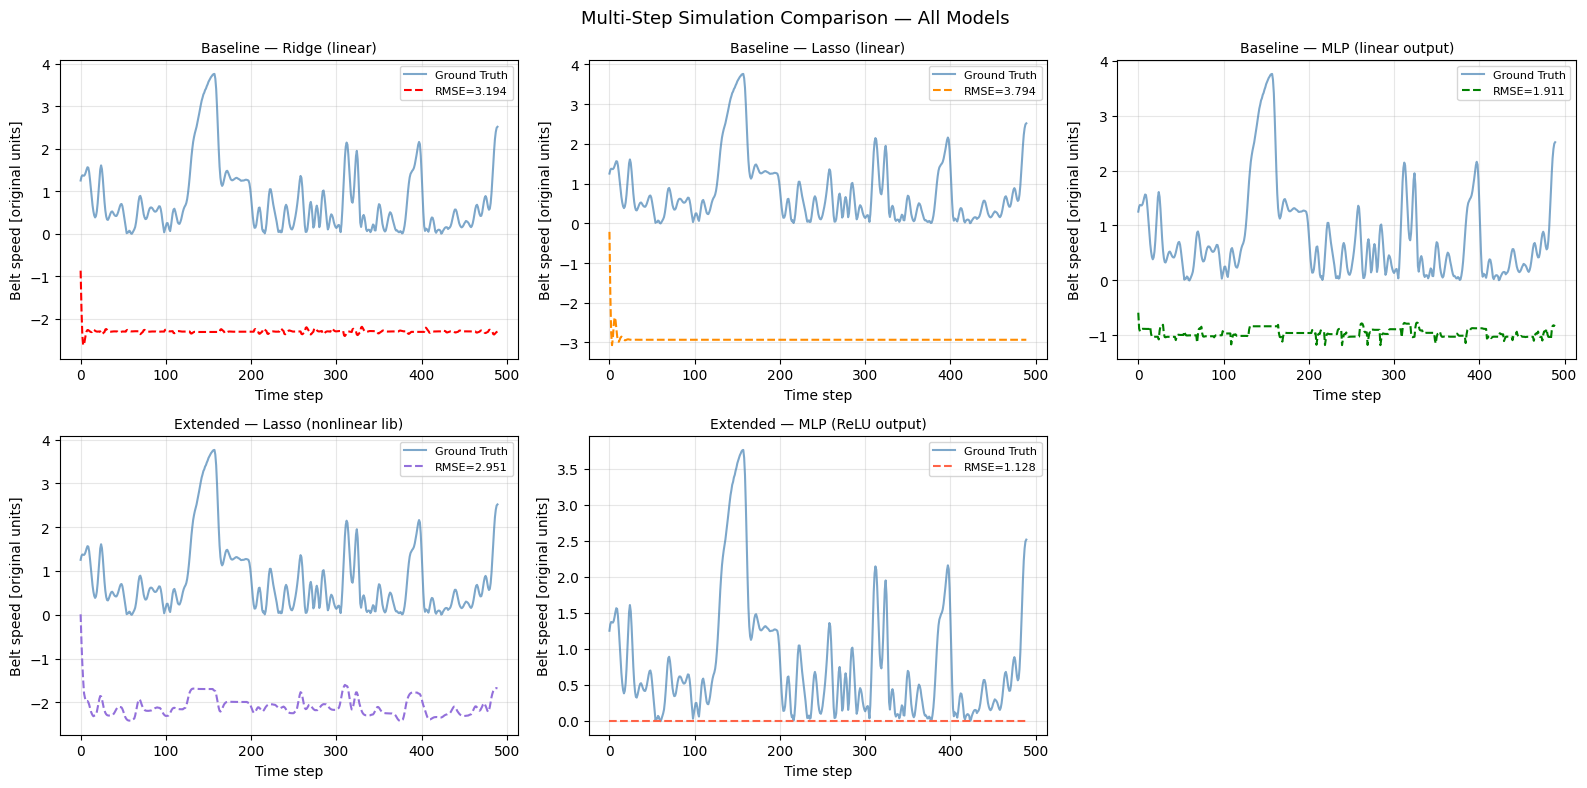

'\nfig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=True)\nfig.suptitle("Multi-Step Simulation Comparison — All Models", fontsize=13)\nfor ax, (name, sim, color) in zip(axes, models_5):\n    ax.plot(t_ax5, truth_phys5, label="Ground Truth",\n            color="steelblue", linewidth=1.5, alpha=0.7)\n    ax.plot(t_ax5, sim,\n            label=f"RMSE={rmse(sim, truth_phys5):.3f}",\n            color=color, linewidth=1.5, linestyle="--")\n    ax.set_title(name, fontsize=10)\n    ax.set_xlabel("Time step")\n    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)\n\naxes[0].set_ylabel("Belt speed [original units]")\nplt.tight_layout()\nplt.savefig("simulation_all_models.png", dpi=150, bbox_inches="tight")\nplt.show()\n'

In [ ]:
y_sim_lib = simulate_narx_library(
    lambda x: (x @ lib_best_w),
    u_test, y_test_norm,
    na=lib_lag, nb=lib_lag,
    norm_stats=lib_split["norm_stats"],
    y_stats=lib_split["y_stats"]
)
y_sim_relu = simulate_narx(
    lambda x: nn_relu.forward(x).ravel(),
    u_test, y_test_norm,
    na=mlp_best_lag, nb=mlp_best_lag,
    norm_stats=relu_split["norm_stats"],
    y_stats=relu_split["y_stats"]
)

# Align all 5 to shortest length
min_len = min(len(y_sim_ridge), len(y_sim_lasso), len(y_sim_mlp),
              len(y_sim_lib),   len(y_sim_relu))
global_max_lag = max(ridge_best_lag, lasso_best_lag, mlp_best_lag,
                     lib_lag, mlp_best_lag)
truth_phys5 = y_test_physical[global_max_lag:][:min_len]
t_ax5       = np.arange(min_len)

models_5 = [
    ("Ridge (linear)",          y_sim_ridge[:min_len], "red"),
    ("Lasso (linear)",          y_sim_lasso[:min_len], "darkorange"),
    ("MLP (linear output)",     y_sim_mlp[:min_len],   "green"),
    ("Lasso (nonlinear lib)",   y_sim_lib[:min_len],   "mediumpurple"),
    ("MLP (ReLU output)",       y_sim_relu[:min_len],  "tomato"),
]

print("Multi-step simulation RMSE — all models (physical units):")
print("-" * 50)
for name, sim, _ in models_5:
    print(f"  {name:<28}: {rmse(sim, truth_phys5):.5f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Multi-Step Simulation Comparison — All Models", fontsize=13)

# Row 1: Baseline models (leave third panel blank)
baseline = [
    ("Ridge (linear)",      y_sim_ridge[:min_len], "red"),
    ("Lasso (linear)",      y_sim_lasso[:min_len], "darkorange"),
    ("MLP (linear output)", y_sim_mlp[:min_len],   "green"),
]
for ax, (name, sim, color) in zip(axes[0], baseline):
    ax.plot(t_ax5, truth_phys5, label="Ground Truth",
            color="steelblue", linewidth=1.5, alpha=0.7)
    ax.plot(t_ax5, sim,
            label=f"RMSE={rmse(sim, truth_phys5):.3f}",
            color=color, linewidth=1.5, linestyle="--")
    ax.set_title(f"Baseline — {name}", fontsize=10)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Belt speed [original units]")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Row 2: Extended models (center the two plots, hide third axis)
extended = [
    ("Lasso (nonlinear lib)", y_sim_lib[:min_len],  "mediumpurple"),
    ("MLP (ReLU output)",     y_sim_relu[:min_len], "tomato"),
]
for ax, (name, sim, color) in zip(axes[1, :2], extended):
    ax.plot(t_ax5, truth_phys5, label="Ground Truth",
            color="steelblue", linewidth=1.5, alpha=0.7)
    ax.plot(t_ax5, sim,
            label=f"RMSE={rmse(sim, truth_phys5):.3f}",
            color=color, linewidth=1.5, linestyle="--")
    ax.set_title(f"Extended — {name}", fontsize=10)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Belt speed [original units]")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Hide the unused third axis in row 2
axes[1, 2].axis("off")

plt.tight_layout()
plt.savefig("simulation_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
'''
fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=True)
fig.suptitle("Multi-Step Simulation Comparison — All Models", fontsize=13)
for ax, (name, sim, color) in zip(axes, models_5):
    ax.plot(t_ax5, truth_phys5, label="Ground Truth",
            color="steelblue", linewidth=1.5, alpha=0.7)
    ax.plot(t_ax5, sim,
            label=f"RMSE={rmse(sim, truth_phys5):.3f}",
            color=color, linewidth=1.5, linestyle="--")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Time step")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Belt speed [original units]")
plt.tight_layout()
plt.savefig("simulation_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
'''

To investigate whether the MLP simulation failure stemmed from violations of the physical non-negativity constraint $(y \geq 0)$, we computed the normalized floor value $y_{\text{floor,norm}} = (0 - \bar{y})/\sigma_y = -1.109$ and verified that all model predictions exceeded this threshold. The MLP implicitly learned the non-negativity constraint from the training distribution without explicit architectural enforcement, ruling out constraint violation as a contributing factor to the simulation error. The simulation divergence is therefore attributed entirely to distribution shift under autoregressive feedback — a known limitation of open-loop identification methods applied in closed-loop simulation.